In [2]:

import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='jYCzRmjSv9C75hrjlyXSAmYxZwDh7WyW_YtcwDr5UZ2p',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.au-syd.cloud-object-storage.appdomain.cloud')

bucket = 'nsapschemeeligibilityprediction-donotdelete-pr-ohv5yjukjmwlpw'
object_key = 'DistrictwisePensiondataundertheNationalSocialAssistanceProgrammeNSAP.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_0 = pd.read_csv(body)
df_0.head(10)


,finyear,lgdstatecode,statename,lgddistrictcode,districtname,schemecode,totalbeneficiaries,totalmale,totalfemale,totaltransgender,totalsc,totalst,totalgen,totalobc,totalaadhaar,totalmpbilenumber
0,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNDPS,107,71,36,0,0,2,104,1,107,69
1,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNOAPS,8393,5037,3356,0,37,232,8039,85,8327,7162
2,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNWPS,203,0,203,0,1,15,181,6,201,160
3,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNDPS,310,211,99,0,0,77,200,33,234,110
4,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNOAPS,5959,3959,2000,0,2,1347,4368,242,3873,2287
5,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNWPS,382,0,382,0,0,65,298,19,260,90
6,2025-2026,1,JAMMU AND KASHMIR,11,PULWAMA,IGNDPS,95,63,32,0,0,6,81,8,94,93
7,2025-2026,1,JAMMU AND KASHMIR,11,PULWAMA,IGNOAPS,5037,2922,2115,0,1,197,4458,381,5037,4950
8,2025-2026,1,JAMMU AND KASHMIR,11,PULWAMA,IGNWPS,304,0,304,0,0,20,260,24,304,258
9,2025-2026,1,JAMMU AND KASHMIR,12,RAJAURI,IGNDPS,77,52,25,0,5,5,67,0,71,2


In [3]:
df = df_0.copy()

print(df.shape)
df.head()

(100, 16)


,finyear,lgdstatecode,statename,lgddistrictcode,districtname,schemecode,totalbeneficiaries,totalmale,totalfemale,totaltransgender,totalsc,totalst,totalgen,totalobc,totalaadhaar,totalmpbilenumber
0,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNDPS,107,71,36,0,0,2,104,1,107,69
1,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNOAPS,8393,5037,3356,0,37,232,8039,85,8327,7162
2,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNWPS,203,0,203,0,1,15,181,6,201,160
3,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNDPS,310,211,99,0,0,77,200,33,234,110
4,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNOAPS,5959,3959,2000,0,2,1347,4368,242,3873,2287


In [4]:
# Basic Information

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nStatistics")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   finyear             100 non-null    object
 1   lgdstatecode        100 non-null    int64 
 2   statename           100 non-null    object
 3   lgddistrictcode     100 non-null    int64 
 4   districtname        100 non-null    object
 5   schemecode          100 non-null    object
 6   totalbeneficiaries  100 non-null    int64 
 7   totalmale           100 non-null    int64 
 8   totalfemale         100 non-null    int64 
 9   totaltransgender    100 non-null    int64 
 10  totalsc             100 non-null    int64 
 11  totalst             100 non-null    int64 
 12  totalgen            100 non-null    int64 
 13  totalobc            100 non-null    int64 
 14  totalaadhaar        100 non-null    int64 
 15  totalmpbilenumber   100 non-null    int64 
dtypes: int64(12), object(4)
mem

,lgdstatecode,lgddistrictcode,totalbeneficiaries,totalmale,totalfemale,totaltransgender,totalsc,totalst,totalgen,totalobc,totalaadhaar,totalmpbilenumber
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.00000,100.00000,100.000000,100.000000
mean,4.600000,230.010000,14950.910000,6459.660000,8487.320000,3.93000,2850.690000,319.080000,9580.28000,2200.86000,12401.470000,11677.970000
std,4.431294,236.796059,31612.334695,15517.913915,16662.613827,17.80322,7776.502001,649.649458,21418.47706,6043.40252,25890.079585,25221.317209
min,1.000000,1.000000,26.000000,0.000000,7.000000,0.00000,0.000000,0.000000,16.00000,0.00000,24.000000,2.000000
25%,1.000000,11.000000,250.250000,0.000000,227.000000,0.00000,1.000000,10.750000,231.25000,1.00000,233.000000,125.250000
50%,1.000000,192.000000,2250.000000,101.500000,833.500000,0.00000,61.500000,61.500000,1632.50000,83.00000,1906.000000,1405.000000
75%,10.000000,200.250000,8506.250000,2937.750000,5972.250000,0.00000,1416.000000,275.500000,7402.75000,837.75000,8142.500000,6821.750000
max,10.000000,627.000000,150531.000000,75932.000000,81899.000000,165.00000,61247.000000,3642.000000,107472.00000,31048.00000,127281.000000,126054.000000


In [5]:
print(df.columns.tolist())

['finyear', 'lgdstatecode', 'statename', 'lgddistrictcode', 'districtname', 'schemecode', 'totalbeneficiaries', 'totalmale', 'totalfemale', 'totaltransgender', 'totalsc', 'totalst', 'totalgen', 'totalobc', 'totalaadhaar', 'totalmpbilenumber']


In [6]:
# Feature Engineering

df["male_pct"] = df["totalmale"] / df["totalbeneficiaries"]
df["female_pct"] = df["totalfemale"] / df["totalbeneficiaries"]
df["transgender_pct"] = df["totaltransgender"] / df["totalbeneficiaries"]

df["sc_pct"] = df["totalsc"] / df["totalbeneficiaries"]
df["st_pct"] = df["totalst"] / df["totalbeneficiaries"]
df["general_pct"] = df["totalgen"] / df["totalbeneficiaries"]
df["obc_pct"] = df["totalobc"] / df["totalbeneficiaries"]

df["aadhaar_coverage_pct"] = df["totalaadhaar"] / df["totalbeneficiaries"]
df["mobile_coverage_pct"] = df["totalmpbilenumber"] / df["totalbeneficiaries"]

# Beneficiary density
df["beneficiary_density"] = (
    df["totalbeneficiaries"] /
    df["totalbeneficiaries"].max()
)

df.head()

,finyear,lgdstatecode,statename,lgddistrictcode,districtname,schemecode,totalbeneficiaries,totalmale,totalfemale,totaltransgender,...,male_pct,female_pct,transgender_pct,sc_pct,st_pct,general_pct,obc_pct,aadhaar_coverage_pct,mobile_coverage_pct,beneficiary_density
0,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNDPS,107,71,36,0,...,0.663551,0.336449,0.0,0.000000,0.018692,0.971963,0.009346,1.000000,0.644860,0.000711
1,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNOAPS,8393,5037,3356,0,...,0.600143,0.399857,0.0,0.004408,0.027642,0.957822,0.010127,0.992136,0.853330,0.055756
2,2025-2026,1,JAMMU AND KASHMIR,1,ANANTNAG,IGNWPS,203,0,203,0,...,0.000000,1.000000,0.0,0.004926,0.073892,0.891626,0.029557,0.990148,0.788177,0.001349
3,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNDPS,310,211,99,0,...,0.680645,0.319355,0.0,0.000000,0.248387,0.645161,0.106452,0.754839,0.354839,0.002059
4,2025-2026,1,JAMMU AND KASHMIR,10,POONCH,IGNOAPS,5959,3959,2000,0,...,0.664373,0.335627,0.0,0.000336,0.226045,0.733009,0.040611,0.649941,0.383789,0.039587


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [8]:
FEATURES = [
    "male_pct",
    "female_pct",
    "transgender_pct",
    "sc_pct",
    "st_pct",
    "general_pct",
    "obc_pct",
    "aadhaar_coverage_pct",
    "mobile_coverage_pct",
    "beneficiary_density"
]

X = df[FEATURES]
y = df["schemecode"]

print(X.head())
print(y.head())

   male_pct  female_pct  transgender_pct    sc_pct    st_pct  general_pct  \
0  0.663551    0.336449              0.0  0.000000  0.018692     0.971963   
1  0.600143    0.399857              0.0  0.004408  0.027642     0.957822   
2  0.000000    1.000000              0.0  0.004926  0.073892     0.891626   
3  0.680645    0.319355              0.0  0.000000  0.248387     0.645161   
4  0.664373    0.335627              0.0  0.000336  0.226045     0.733009   

    obc_pct  aadhaar_coverage_pct  mobile_coverage_pct  beneficiary_density  
0  0.009346              1.000000             0.644860             0.000711  
1  0.010127              0.992136             0.853330             0.055756  
2  0.029557              0.990148             0.788177             0.001349  
3  0.106452              0.754839             0.354839             0.002059  
4  0.040611              0.649941             0.383789             0.039587  
0     IGNDPS
1    IGNOAPS
2     IGNWPS
3     IGNDPS
4    IGNOAPS
Name

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)

['IGNDPS' 'IGNOAPS' 'IGNWPS']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [13]:
pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))

print("\nClassification Report\n")
print(classification_report(y_test, pred))

Accuracy : 0.85

Classification Report

              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       1.00      0.57      0.73         7
           2       1.00      1.00      1.00         6

    accuracy                           0.85        20
   macro avg       0.90      0.86      0.85        20
weighted avg       0.89      0.85      0.84        20



<Figure size 600x600 with 0 Axes>

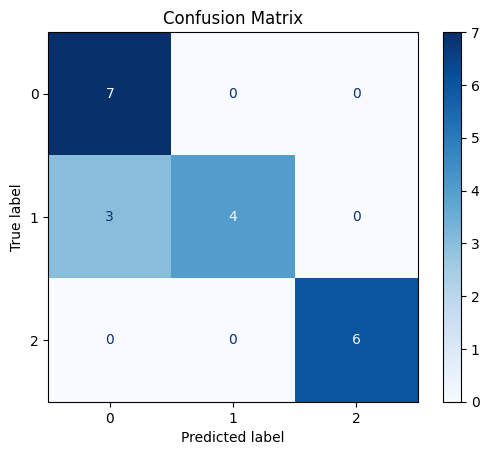

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

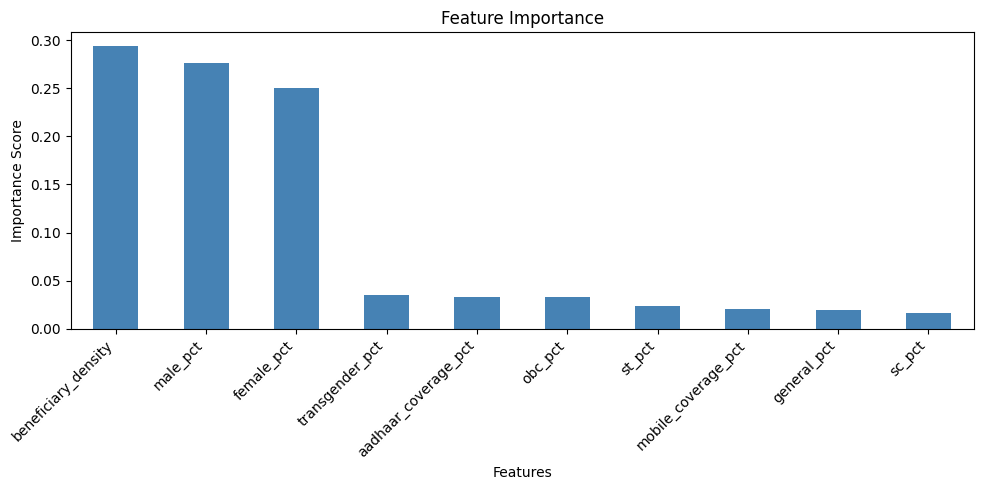

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind="bar", color="steelblue")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [16]:
import pandas as pd

# 5 sample records
sample = X_test[:5]

pred = model.predict(sample)

result = pd.DataFrame({
    "Actual Scheme": le.inverse_transform(y_test[:5]),
    "Predicted Scheme": le.inverse_transform(pred)
})

result

,Actual Scheme,Predicted Scheme
0,IGNDPS,IGNDPS
1,IGNWPS,IGNWPS
2,IGNDPS,IGNDPS
3,IGNDPS,IGNDPS
4,IGNOAPS,IGNDPS


In [17]:
import os
os.getcwd()

'/home/wsuser/work'

In [22]:
import os

print("Current Directory:", os.getcwd())
print("Files:", os.listdir())

Current Directory: /home/wsuser/work
Files: []


In [23]:
joblib.dump(model, "nsap_model.pkl")
joblib.dump(scaler, "nsap_scaler.pkl")
joblib.dump(le, "nsap_label_encoder.pkl")
joblib.dump(FEATURES, "nsap_features.pkl")

print("All files saved successfully!")

All files saved successfully!


In [24]:
import os

os.listdir()

['nsap_label_encoder.pkl',
 'nsap_features.pkl',
 'nsap_model.pkl',
 'nsap_scaler.pkl']

In [26]:
app_code = '''
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

model = joblib.load("nsap_model.pkl")
scaler = joblib.load("nsap_scaler.pkl")
label = joblib.load("nsap_label_encoder.pkl")
FEATURES = joblib.load("nsap_features.pkl")

@app.route("/")
def home():
    return """
    <h1>NSAP Scheme Eligibility Prediction</h1>
    <p>API is Running Successfully</p>
    """

@app.route("/predict", methods=["POST"])
def predict():

    data = request.json

    df = pd.DataFrame([data])

    df = df[FEATURES]

    df = scaler.transform(df)

    pred = model.predict(df)

    scheme = label.inverse_transform(pred)[0]

    return jsonify({
        "Predicted Scheme": scheme
    })


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8080)
'''

with open("app.py","w") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [27]:
import os
os.listdir()

['app.py',
 'nsap_project.zip',
 'nsap_label_encoder.pkl',
 'nsap_features.pkl',
 'nsap_model.pkl',
 'nsap_scaler.pkl']

In [28]:
requirements = """
flask==3.0.3
scikit-learn==1.5.1
pandas==2.2.2
numpy==1.26.4
joblib==1.4.2
gunicorn==22.0.0
"""

with open("requirements.txt","w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [29]:
dockerfile = """
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8080

CMD ["gunicorn","--bind","0.0.0.0:8080","app:app"]
"""

with open("Dockerfile","w") as f:
    f.write(dockerfile)

print("Dockerfile created")

Dockerfile created


In [30]:
import os
os.listdir()

['app.py',
 'nsap_project.zip',
 'nsap_label_encoder.pkl',
 'nsap_features.pkl',
 'nsap_model.pkl',
 'requirements.txt',
 'nsap_scaler.pkl',
 'Dockerfile']

In [31]:
app_code = r'''
from flask import Flask, request, jsonify, render_template_string
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load("nsap_model.pkl")
scaler = joblib.load("nsap_scaler.pkl")
le = joblib.load("nsap_label_encoder.pkl")
FEATURES = joblib.load("nsap_features.pkl")

SCHEME_NAMES = {
    "IGNOAPS": "Indira Gandhi National Old Age Pension Scheme",
    "IGNWPS": "Indira Gandhi National Widow Pension Scheme",
    "IGNDPS": "Indira Gandhi National Disability Pension Scheme",
}

HOME_PAGE = """
<!DOCTYPE html>
<html>
<head>
<title>NSAP Scheme Eligibility Predictor</title>

<style>

body{
font-family:Arial;
background:#f4f6fa;
padding:40px;
}

.container{
max-width:700px;
margin:auto;
background:white;
padding:25px;
border-radius:10px;
box-shadow:0px 0px 15px #ccc;
}

h2{
text-align:center;
color:#004080;
}

input{
width:100%;
padding:10px;
margin-top:5px;
margin-bottom:15px;
}

button{
width:100%;
padding:12px;
background:#004080;
color:white;
border:none;
cursor:pointer;
font-size:18px;
}

#result{
margin-top:20px;
font-size:20px;
font-weight:bold;
color:green;
}

</style>

</head>

<body>

<div class="container">

<h2>NSAP Scheme Eligibility Predictor</h2>

<label>Male %</label>
<input id="male_pct" value="0.5">

<label>Female %</label>
<input id="female_pct" value="0.5">

<label>Transgender %</label>
<input id="transgender_pct" value="0">

<label>SC %</label>
<input id="sc_pct" value="0.1">

<label>ST %</label>
<input id="st_pct" value="0.1">

<label>General %</label>
<input id="gen_pct" value="0.6">

<label>OBC %</label>
<input id="obc_pct" value="0.2">

<label>Aadhaar Coverage %</label>
<input id="aadhaar_coverage_pct" value="0.9">

<label>Mobile Coverage %</label>
<input id="mobile_coverage_pct" value="0.7">

<label>Beneficiary Density</label>
<input id="beneficiary_density" value="0.3">

<button onclick="predict()">Predict Scheme</button>

<div id="result"></div>

</div>

<script>

async function predict(){

let payload={};

document.querySelectorAll("input").forEach(x=>{
payload[x.id]=parseFloat(x.value);
});

const response=await fetch("/predict",{

method:"POST",

headers:{
"Content-Type":"application/json"
},

body:JSON.stringify(payload)

});

const data=await response.json();

document.getElementById("result").innerHTML=
"<br><b>"+data.scheme_name+"</b><br>Confidence : "+(data.confidence*100).toFixed(2)+"%";

}

</script>

</body>
</html>
"""

@app.route("/")
def home():
    return render_template_string(HOME_PAGE)

@app.route("/predict",methods=["POST"])
def predict():

    data=request.json

    x=np.array([[data.get(f,0) for f in FEATURES]])

    x=scaler.transform(x)

    pred=model.predict(x)[0]

    proba=model.predict_proba(x)[0]

    scheme=le.inverse_transform([pred])[0]

    return jsonify({

    "scheme_code":scheme,

    "scheme_name":SCHEME_NAMES.get(scheme,scheme),

    "confidence":float(max(proba))

    })

@app.route("/health")
def health():
    return {"status":"ok"}

if __name__=="__main__":
    app.run(host="0.0.0.0",port=8080)
'''

with open("app.py","w") as f:
    f.write(app_code)

print("Professional app.py created")

Professional app.py created


In [24]:
!python app.py

Traceback (most recent call last):
  File "/home/wsuser/work/app.py", line 2, in <module>
    from flask import Flask, request, jsonify, render_template_string
ModuleNotFoundError: No module named 'flask'


In [25]:
!pip install flask gunicorn joblib scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [flask]32m2/4 [blinker]


In [33]:
import os
os.listdir()

['app.py',
 'nsap_features.pkl',
 'nsap_label_encoder.pkl',
 'requirements.txt',
 'nsap_model.pkl',
 'nsap_scaler.pkl',
 'Dockerfile']

In [34]:
type(model)

sklearn.ensemble._forest.RandomForestClassifier

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

NameError: name 'model' is not defined

In [32]:
!zip -r nsap_project.zip \
nsap_model.pkl \
nsap_scaler.pkl \
nsap_label_encoder.pkl \
nsap_features.pkl \
app.py \
requirements.txt \
Dockerfile

updating: nsap_model.pkl (deflated 86%)
updating: nsap_scaler.pkl (deflated 29%)
updating: nsap_label_encoder.pkl (deflated 28%)
updating: nsap_features.pkl (deflated 34%)
  adding: app.py (deflated 55%)
  adding: requirements.txt (deflated 12%)
  adding: Dockerfile (deflated 19%)


In [33]:
import os
os.listdir()

['app.py',
 'nsap_project.zip',
 'nsap_label_encoder.pkl',
 'nsap_features.pkl',
 'nsap_model.pkl',
 'requirements.txt',
 'nsap_scaler.pkl',
 'Dockerfile']